In [31]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# CSV 파일 로드
df = pd.read_csv('total_game_api_data.csv')

# 게시일 컬럼을 datetime으로 변환
df['게시일'] = pd.to_datetime(df['게시일'])
df['조회수'] = pd.to_numeric(df['viewCount'], errors='coerce')

# 채널별로 정렬
df = df.sort_values(['채널명', '게시일'])

def calculate_upload_frequency(channel_df):
    """채널별 업로드 주기 계산"""
    if len(channel_df) < 2:
        return None

    # 연속된 업로드 간격 계산
    upload_gaps = []
    dates = channel_df['게시일'].sort_values()

    for i in range(1, len(dates)):
        gap = (dates.iloc[i] - dates.iloc[i-1]).days
        upload_gaps.append(gap)

    return {
        'avg_gap_days': np.mean(upload_gaps),
        'median_gap_days': np.median(upload_gaps),
        'std_gap_days': np.std(upload_gaps),
        'total_videos': len(channel_df),
        'period_days': (dates.max() - dates.min()).days,
        'videos_per_week': len(channel_df) / ((dates.max() - dates.min()).days / 7) if (dates.max() - dates.min()).days > 0 else 0
    }

# 채널별 업로드 주기 분석
channel_stats = []
for channel in df['채널명'].unique():
    channel_df = df[df['채널명'] == channel]
    freq_stats = calculate_upload_frequency(channel_df)

    if freq_stats:
        channel_stats.append({
            'channel': channel,
            'avg_views': channel_df['조회수'].mean(),
            'median_views': channel_df['조회수'].median(),
            'total_views': channel_df['조회수'].sum(),
            'subscriber_count': channel_df['구독자수'].iloc[0] if not channel_df['구독자수'].isna().all() else 0,
            **freq_stats
        })

upload_analysis = pd.DataFrame(channel_stats)

def calculate_upload_frequency(channel_df):
    """채널별 업로드 주기 계산"""
    if len(channel_df) < 2:
        return None

    # 연속된 업로드 간격 계산
    upload_gaps = []
    dates = channel_df['게시일'].sort_values()

    for i in range(1, len(dates)):
        gap = (dates.iloc[i] - dates.iloc[i-1]).days
        upload_gaps.append(gap)

    return {
        'avg_gap_days': np.mean(upload_gaps),
        'median_gap_days': np.median(upload_gaps),
        'std_gap_days': np.std(upload_gaps),
        'total_videos': len(channel_df),
        'period_days': (dates.max() - dates.min()).days,
        'videos_per_week': len(channel_df) / ((dates.max() - dates.min()).days / 7) if (dates.max() - dates.min()).days > 0 else 0
    }

# 채널별 업로드 주기 분석
channel_stats = []
for channel in df['채널명'].unique():
    channel_df = df[df['채널명'] == channel]
    freq_stats = calculate_upload_frequency(channel_df)

    if freq_stats:
        channel_stats.append({
            'channel': channel,
            'avg_views': channel_df['조회수'].mean(),
            'median_views': channel_df['조회수'].median(),
            'total_views': channel_df['조회수'].sum(),
            'subscriber_count': channel_df['구독자수'].iloc[0] if not channel_df['구독자수'].isna().all() else 0,
            **freq_stats
        })

upload_analysis = pd.DataFrame(channel_stats)

# 업로드 주기와 조회수 상관관계 분석
correlation_results = {}

# 1) 업로드 빈도와 평균 조회수
corr_freq_views = stats.pearsonr(upload_analysis['videos_per_week'],
                                upload_analysis['avg_views'])
correlation_results['frequency_vs_avg_views'] = corr_freq_views

# 2) 업로드 간격과 조회수
corr_gap_views = stats.pearsonr(upload_analysis['avg_gap_days'],
                               upload_analysis['avg_views'])
correlation_results['gap_vs_views'] = corr_gap_views

# 3) 업로드 일관성(표준편차)과 조회수
upload_analysis_clean = upload_analysis.dropna(subset=['std_gap_days'])
if len(upload_analysis_clean) > 0:
    corr_consistency_views = stats.pearsonr(upload_analysis_clean['std_gap_days'],
                                          upload_analysis_clean['avg_views'])
    correlation_results['consistency_vs_views'] = corr_consistency_views

print("상관관계 분석 결과:")
for key, (corr, p_value) in correlation_results.items():
    print(f"{key}: 상관계수 = {corr:.3f}, p-value = {p_value:.3f}")

# 게임별 업로드 패턴 분석
game_upload_analysis = []
for game in df['게임명'].unique():
    game_df = df[df['게임명'] == game]

    for channel in game_df['채널명'].unique():
        channel_game_df = game_df[game_df['채널명'] == channel]
        if len(channel_game_df) >= 3:  # 최소 3개 영상
            freq_stats = calculate_upload_frequency(channel_game_df)
            if freq_stats:
                game_upload_analysis.append({
                    'game': game,
                    'channel': channel,
                    'avg_views': channel_game_df['조회수'].mean(),
                    **freq_stats
                })

game_analysis_df = pd.DataFrame(game_upload_analysis)

# 게임별 업로드 패턴과 조회수 관계
game_correlations = {}
for game in game_analysis_df['game'].unique():
    game_data = game_analysis_df[game_analysis_df['game'] == game]
    if len(game_data) >= 5:  # 충분한 샘플 수
        corr, p_val = stats.pearsonr(game_data['videos_per_week'], game_data['avg_views'])
        game_correlations[game] = (corr, p_val)

print("\n게임별 업로드 빈도-조회수 상관관계:")
for game, (corr, p_val) in game_correlations.items():
    print(f"{game}: {corr:.3f} (p={p_val:.3f})")


상관관계 분석 결과:
frequency_vs_avg_views: 상관계수 = -0.061, p-value = 0.002
gap_vs_views: 상관계수 = 0.046, p-value = 0.017
consistency_vs_views: 상관계수 = 0.095, p-value = 0.000

게임별 업로드 빈도-조회수 상관관계:
발로란트: -0.040 (p=0.409)
롤: -0.092 (p=0.051)
FC온라인: -0.070 (p=0.308)
배틀그라운드: -0.038 (p=0.447)
서든: -0.074 (p=0.288)


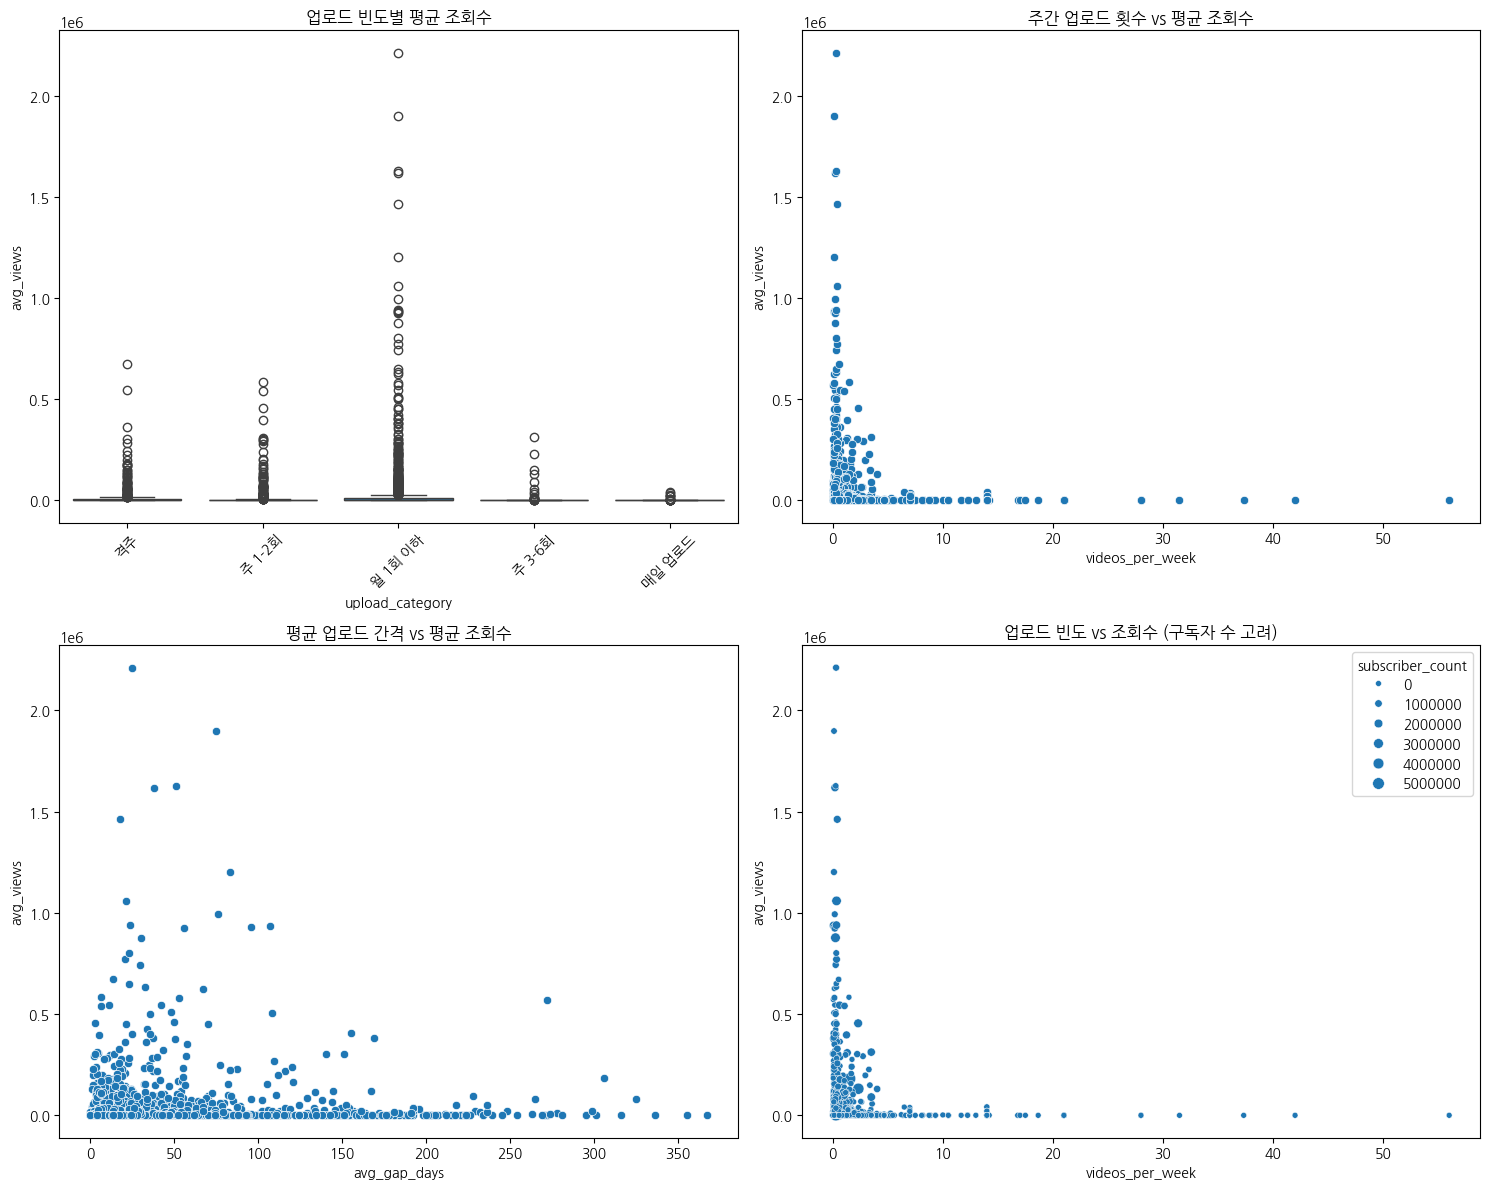

In [24]:

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 나눔고딕으로 폰트 설정
plt.rc('font', family='NanumGothic')

# 마이너스 부호 깨지는 것 방지
mpl.rcParams['axes.unicode_minus'] = False


# 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1) 업로드 빈도별 평균 조회수
sns.boxplot(data=upload_analysis, x='upload_category', y='avg_views', ax=axes[0,0])
axes[0,0].set_title('업로드 빈도별 평균 조회수')
axes[0,0].tick_params(axis='x', rotation=45)

# 2) 업로드 빈도와 조회수 산점도
sns.scatterplot(data=upload_analysis, x='videos_per_week', y='avg_views', ax=axes[0,1])
axes[0,1].set_title('주간 업로드 횟수 vs 평균 조회수')

# 3) 업로드 간격과 조회수
sns.scatterplot(data=upload_analysis, x='avg_gap_days', y='avg_views', ax=axes[1,0])
axes[1,0].set_title('평균 업로드 간격 vs 평균 조회수')

# 4) 구독자 수 고려한 분석
sns.scatterplot(data=upload_analysis, x='videos_per_week', y='avg_views',
                size='subscriber_count', ax=axes[1,1])
axes[1,1].set_title('업로드 빈도 vs 조회수 (구독자 수 고려)')

plt.tight_layout()
plt.show()


In [26]:
# 업로드 카테고리별 성과 분석
category_performance = upload_analysis.groupby('upload_category').agg({
    'avg_views': ['mean', 'median', 'std'],
    'total_views': 'mean',
    'subscriber_count': 'mean'
}).round(2)

print("\n업로드 주기별 성과 분석:")
print(category_performance)

# 통계적 유의성 검정 (ANOVA)
from scipy.stats import f_oneway

categories = upload_analysis['upload_category'].unique()
category_views = [upload_analysis[upload_analysis['upload_category'] == cat]['avg_views'].values
                 for cat in categories]

f_stat, p_value = f_oneway(*category_views)
print(f"\nANOVA 검정 결과: F-statistic = {f_stat:.3f}, p-value = {p_value:.3f}")



업로드 주기별 성과 분석:
                avg_views                    total_views subscriber_count
                     mean  median        std        mean             mean
upload_category                                                          
격주               17388.91  409.33   57751.87   358613.51         43325.37
매일 업로드            1715.51   43.60    6285.79     6450.78          2969.93
월 1회 이하          37120.46  574.92  149286.15   267430.84         59391.70
주 1-2회           16473.81  213.96   59335.00   841857.19         49138.13
주 3-6회            8893.65   79.57   38953.39   864729.43         42854.40

ANOVA 검정 결과: F-statistic = 6.930, p-value = 0.000


In [19]:
import pandas as pd
import numpy as np
from datetime import datetime

def calculate_upload_cycle_per_youtuber(csv_file_path):
    """유튜버별 업로드 주기 계산 및 CSV 저장"""

    # CSV 파일 로드
    df = pd.read_csv(csv_file_path, encoding='UTF-8')

    # 게시일을 datetime으로 변환
    df['게시일'] = pd.to_datetime(df['게시일'])

    # 채널별로 정렬
    df = df.sort_values(['채널명', '게시일'])

    # 유튜버별 업로드 주기 계산
    youtuber_upload_cycles = []

    for channel in df['채널명'].unique():
        channel_df = df[df['채널명'] == channel].copy()

        if len(channel_df) < 2:
            # 영상이 1개 이하인 경우
            youtuber_upload_cycles.append({
                '채널명': channel,
                '총_영상수': len(channel_df),
                '평균_업로드_주기_일': None,
                '중간값_업로드_주기_일': None,
                '최소_업로드_간격_일': None,
                '최대_업로드_간격_일': None,
                '업로드_주기_표준편차': None,
                '주간_평균_업로드_횟수': None,
                '월간_평균_업로드_횟수': None,
                '분석_기간_일수': None,
                '첫_업로드일': channel_df['게시일'].min(),
                '마지막_업로드일': channel_df['게시일'].max(),
                '업로드_일관성': 'N/A',
                '비고': '영상수 부족'
            })
            continue

        # 업로드 날짜 정렬
        upload_dates = channel_df['게시일'].sort_values()

        # 연속된 업로드 간의 간격 계산 (일 단위)
        upload_gaps = []
        for i in range(1, len(upload_dates)):
            gap_days = (upload_dates.iloc[i] - upload_dates.iloc[i-1]).days
            upload_gaps.append(gap_days)

        # 분석 기간
        total_period_days = (upload_dates.max() - upload_dates.min()).days

        # 통계 계산
        avg_gap = np.mean(upload_gaps)
        median_gap = np.median(upload_gaps)
        min_gap = np.min(upload_gaps)
        max_gap = np.max(upload_gaps)
        std_gap = np.std(upload_gaps)

        # 주간/월간 업로드 횟수
        videos_per_week = len(channel_df) / (total_period_days / 7) if total_period_days > 0 else 0
        videos_per_month = len(channel_df) / (total_period_days / 30) if total_period_days > 0 else 0

        # 업로드 일관성 평가
        if std_gap <= avg_gap * 0.3:
            consistency = '매우 일관적'
        elif std_gap <= avg_gap * 0.6:
            consistency = '일관적'
        elif std_gap <= avg_gap * 1.0:
            consistency = '보통'
        else:
            consistency = '불규칙적'

        youtuber_upload_cycles.append({
            '채널명': channel,
            '총_영상수': len(channel_df),
            '평균_업로드_주기_일': round(avg_gap, 2),
            '중간값_업로드_주기_일': round(median_gap, 2),
            '최소_업로드_간격_일': min_gap,
            '최대_업로드_간격_일': max_gap,
            '업로드_주기_표준편차': round(std_gap, 2),
            '주간_평균_업로드_횟수': round(videos_per_week, 2),
            '월간_평균_업로드_횟수': round(videos_per_month, 2),
            '분석_기간_일수': total_period_days,
            '첫_업로드일': upload_dates.min(),
            '마지막_업로드일': upload_dates.max(),
            '업로드_일관성': consistency,
            '비고': '정상 분석'
        })

    # DataFrame으로 변환
    result_df = pd.DataFrame(youtuber_upload_cycles)

    # 평균 업로드 주기 기준으로 정렬 (수정된 부분)
    result_df = result_df.sort_values('평균_업로드_주기_일', ascending=True)

    return result_df

def save_upload_cycle_analysis(input_csv_path, output_csv_path='유튜버_업로드_주기_분석.csv'):
    """업로드 주기 분석 결과를 CSV로 저장"""

    # 분석 실행
    analysis_result = calculate_upload_cycle_per_youtuber(input_csv_path)

    # CSV로 저장
    analysis_result.to_csv(output_csv_path, index=False, encoding='utf-8-sig')

    # 요약 통계 출력
    print(f"분석 완료! 결과가 '{output_csv_path}'에 저장되었습니다.")
    print(f"\n총 분석된 채널 수: {len(analysis_result)}")
    print(f"정상 분석된 채널 수: {len(analysis_result[analysis_result['비고'] == '정상 분석'])}")

    # 업로드 주기별 분포
    valid_data = analysis_result[analysis_result['평균_업로드_주기_일'].notna()]
    if len(valid_data) > 0:
        print(f"\n업로드 주기 통계:")
        print(f"평균: {valid_data['평균_업로드_주기_일'].mean():.2f}일")
        print(f"중간값: {valid_data['평균_업로드_주기_일'].median():.2f}일")
        print(f"최소: {valid_data['평균_업로드_주기_일'].min():.2f}일")
        print(f"최대: {valid_data['평균_업로드_주기_일'].max():.2f}일")

    return analysis_result

# 사용 예시
if __name__ == "__main__":
    # CSV 파일 경로 설정
    input_file = "total_game_api_data.csv"  # 원본 데이터 파일
    output_file = "유튜버_업로드_주기_분석_결과.csv"  # 결과 저장 파일

    # 분석 실행 및 저장
    result = save_upload_cycle_analysis(input_file, output_file)

    # 상위 10개 채널의 업로드 주기 출력
    print("\n상위 10개 채널 업로드 주기:")
    print(result[['채널명', '평균_업로드_주기_일', '업로드_일관성']].head(10))


분석 완료! 결과가 '유튜버_업로드_주기_분석_결과.csv'에 저장되었습니다.

총 분석된 채널 수: 6175
정상 분석된 채널 수: 2646

업로드 주기 통계:
평균: 35.00일
중간값: 17.00일
최소: 0.00일
최대: 367.00일

상위 10개 채널 업로드 주기:
                  채널명  평균_업로드_주기_일 업로드_일관성
1930              노우석          0.0  매우 일관적
4892             조보미c          0.0  매우 일관적
1886               냥딜          0.0  매우 일관적
169   Clove05 YouTuBe          0.0  매우 일관적
2380           레인보우초림          0.0  매우 일관적
5214               최남          0.0  매우 일관적
1190              강환석          0.0  매우 일관적
2383           레전드 스탐          0.0  매우 일관적
1165              강선혜          0.0  매우 일관적
3045              밤비냥          0.0  매우 일관적


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_upload_frequency_vs_views(upload_cycle_df, original_df):
    """업로드 주기와 조회수 상관관계 분석"""

    # 원본 데이터에서 채널별 평균 조회수 계산
    channel_views = original_df.groupby('채널명').agg({
        'viewCount': ['mean', 'median', 'sum', 'count']
    }).round(2)

    channel_views.columns = ['평균_조회수', '중간값_조회수', '총_조회수', '영상수']
    channel_views = channel_views.reset_index()

    # 업로드 주기 데이터와 조회수 데이터 병합
    merged_df = upload_cycle_df.merge(channel_views, on='채널명', how='inner')

    # 유효한 데이터만 필터링
    valid_df = merged_df[merged_df['평균_업로드_주기_일'].notna()].copy()

    if len(valid_df) == 0:
        print("분석할 유효한 데이터가 없습니다.")
        return

    # 상관관계 분석
    correlations = {}

    # 1. 업로드 주기와 평균 조회수
    corr1, p1 = stats.pearsonr(valid_df['평균_업로드_주기_일'], valid_df['평균_조회수'])
    correlations['업로드주기_vs_평균조회수'] = (corr1, p1)

    # 2. 주간 업로드 횟수와 평균 조회수
    corr2, p2 = stats.pearsonr(valid_df['주간_평균_업로드_횟수'], valid_df['평균_조회수'])
    correlations['주간업로드횟수_vs_평균조회수'] = (corr2, p2)

    # 3. 업로드 일관성과 조회수 (카테고리별)
    consistency_views = valid_df.groupby('업로드_일관성')['평균_조회수'].mean()

    print("=== 업로드 주기와 조회수 상관관계 분석 ===")
    print(f"업로드 주기 vs 평균 조회수: 상관계수 = {corr1:.3f}, p-value = {p1:.3f}")
    print(f"주간 업로드 횟수 vs 평균 조회수: 상관계수 = {corr2:.3f}, p-value = {p2:.3f}")

    print(f"\n업로드 일관성별 평균 조회수:")
    for consistency, avg_views in consistency_views.items():
        print(f"{consistency}: {avg_views:,.0f}회")

    return valid_df, correlations

# 업로드 패턴별 성과 분석
def categorize_upload_patterns_with_views(merged_df):
    """업로드 패턴별 조회수 성과 분석"""

    def get_upload_pattern(avg_days):
        if pd.isna(avg_days):
            return '분석불가'
        elif avg_days <= 1:
            return '매일업로드'
        elif avg_days <= 3:
            return '주2-3회'
        elif avg_days <= 7:
            return '주1회'
        elif avg_days <= 14:
            return '격주'
        elif avg_days <= 30:
            return '월1-2회'
        else:
            return '월1회미만'

    merged_df['업로드_패턴'] = merged_df['평균_업로드_주기_일'].apply(get_upload_pattern)

    # 패턴별 성과 분석
    pattern_analysis = merged_df.groupby('업로드_패턴').agg({
        '채널명': 'count',
        '평균_조회수': ['mean', 'median'],
        '총_조회수': 'mean',
        '평균_업로드_주기_일': 'mean'
    }).round(2)

    pattern_analysis.columns = ['채널수', '평균조회수_평균', '평균조회수_중간값', '총조회수_평균', '평균업로드주기']

    print("\n=== 업로드 패턴별 조회수 성과 ===")
    print(pattern_analysis)

    return pattern_analysis

# 실행 예시
original_df = pd.read_csv("total_game_api_data.csv", encoding='UTF-8')
upload_analysis = save_upload_cycle_analysis("total_game_api_data.csv")

# 상관관계 분석 실행
valid_data, correlations = analyze_upload_frequency_vs_views(upload_analysis, original_df)
pattern_performance = categorize_upload_patterns_with_views(valid_data)


분석 완료! 결과가 '유튜버_업로드_주기_분석.csv'에 저장되었습니다.

총 분석된 채널 수: 6175
정상 분석된 채널 수: 2646

업로드 주기 통계:
평균: 35.00일
중간값: 17.00일
최소: 0.00일
최대: 367.00일
=== 업로드 주기와 조회수 상관관계 분석 ===
업로드 주기 vs 평균 조회수: 상관계수 = 0.046, p-value = 0.017
주간 업로드 횟수 vs 평균 조회수: 상관계수 = -0.061, p-value = 0.002

업로드 일관성별 평균 조회수:
매우 일관적: 16,953회
보통: 31,010회
불규칙적: 36,227회
일관적: 29,301회

=== 업로드 패턴별 조회수 성과 ===
        채널수  평균조회수_평균  평균조회수_중간값     총조회수_평균  평균업로드주기
업로드_패턴                                               
격주      442  17825.43     377.48   349696.21    10.42
매일업로드   252    920.55      35.00     5539.13     0.27
월1-2회   523  36937.28     889.67   436641.55    21.42
월1회미만   910  38267.52     743.75   170684.51    81.98
주1회     340  17666.42     279.22   768127.52     5.13
주2-3회   179  12020.83      73.59  1600693.02     2.14


In [11]:
# ㅅㄷㄴㅅ
# 라이브러리 임포트
from jamo import h2j, j2hcj
from sklearn.cluster import DBSCAN
from rapidfuzz import fuzz
import numpy as np
import pandas as pd
import re
from google.colab import files

print("라이브러리 설치 및 임포트 완료!")

# CSV 파일 업로드
print("CSV 파일을 업로드해주세요:")
uploaded = files.upload()

# 업로드된 파일 처리
csv_filename = None
for filename in uploaded.keys():
    if filename.endswith('.csv'):
        csv_filename = filename
        break

if csv_filename is None:
    print("CSV 파일이 업로드되지 않았습니다. 샘플 데이터를 사용합니다.")
    # 샘플 OCR 텍스트 데이터
    ocr_texts = [
        "전개어리우세요?", "어력우세요?", "전개가 어러우세요?",  # 한글
        "PRESEMT", "PRESEVT", "PRESENT", "RESET", "RESE7",  # 영어
        "할인 50%", "50%6 O", "할이 50%",  # 혼합
        "안녕하세요", "안녕하세요.", "안녕하새요",  # 추가 한글 샘플
        "HELLO", "HEL1O", "HELO",  # 추가 영어 샘플
    ]
else:
    # CSV 파일에서 텍스트 추출
    try:
        df = pd.read_csv(csv_filename, encoding='utf-8')
        print(f"CSV 파일 로드 완료: {csv_filename}")
        print(f"컬럼명: {list(df.columns)}")
        print(f"데이터 형태: {df.shape}")

        # '텍스트' 관련 컬럼 찾기
        text_columns = [col for col in df.columns if any(keyword in col.lower()
                       for keyword in ['텍스트', 'text', '속성', 'content', 'ocr'])]

        if text_columns:
            text_column = text_columns[0]
            print(f"사용할 텍스트 컬럼: {text_column}")

            # 텍스트 데이터 추출 (NaN 값 제거)
            ocr_texts = df[text_column].dropna().astype(str).tolist()

            # 빈 문자열이나 너무 짧은 텍스트 제거
            ocr_texts = [text.strip() for text in ocr_texts if len(text.strip()) > 0]

            print(f"추출된 텍스트 개수: {len(ocr_texts)}")
            print("첫 10개 텍스트 샘플:")
            for i, text in enumerate(ocr_texts[:10]):
                print(f"  {i+1}: {text}")
        else:
            print("텍스트 관련 컬럼을 찾을 수 없습니다. 첫 번째 컬럼을 사용합니다.")
            ocr_texts = df.iloc[:, 0].dropna().astype(str).tolist()
            ocr_texts = [text.strip() for text in ocr_texts if len(text.strip()) > 0]

    except Exception as e:
        print(f"CSV 파일 읽기 오류: {e}")
        print("샘플 데이터를 사용합니다.")
        ocr_texts = [
            "전개어리우세요?", "어력우세요?", "전개가 어러우세요?",
            "PRESEMT", "PRESEVT", "PRESENT", "RESET", "RESE7",
            "할인 50%", "50%6 O", "할이 50%"
        ]

print(f"\n총 {len(ocr_texts)}개의 텍스트로 클러스터링을 수행합니다.")

# 개선된 텍스트 전처리 함수
def preprocess_text(text):
    """
    텍스트 전처리: 불필요한 문자 제거 및 정규화
    """
    # 공백 정리
    text = re.sub(r'\s+', ' ', text.strip())
    # 특수문자 일부 정규화 (OCR 오류 고려)
    text = text.replace('O', '0').replace('l', '1').replace('I', '1')
    return text

# 개선된 유사도 계산 함수
def calculate_similarity_matrix(texts):
    """
    모든 텍스트 쌍에 대해 유사도 행렬 계산
    """
    n = len(texts)
    similarity_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n):
            if i == j:
                similarity_matrix[i][j] = 100.0
            else:
                # 여러 유사도 측정 방법 조합
                ratio_sim = fuzz.ratio(texts[i], texts[j])
                partial_sim = fuzz.partial_ratio(texts[i], texts[j])
                token_sim = fuzz.token_sort_ratio(texts[i], texts[j])

                # 가중 평균으로 최종 유사도 계산
                final_sim = (ratio_sim * 0.5 + partial_sim * 0.3 + token_sim * 0.2)

                similarity_matrix[i][j] = final_sim
                similarity_matrix[j][i] = final_sim

    return similarity_matrix

# 거리 행렬로 변환 (유사도를 거리로)
def similarity_to_distance(similarity_matrix):
    """
    유사도 행렬을 거리 행렬로 변환
    """
    return 100 - similarity_matrix

# 텍스트 전처리
print("텍스트 전처리 중...")
processed_texts = [preprocess_text(text) for text in ocr_texts]

# 유사도 행렬 계산
print("유사도 행렬 계산 중...")
similarity_matrix = calculate_similarity_matrix(processed_texts)

# 거리 행렬로 변환
distance_matrix = similarity_to_distance(similarity_matrix)

# DBSCAN 클러스터링 실행 (거리 행렬 사용)
print("DBSCAN 클러스터링 실행 중...")
# eps 값을 조정하여 적절한 클러스터링 수행
# 낮은 값일수록 더 엄격한 클러스터링, 높은 값일수록 더 관대한 클러스터링
clustering = DBSCAN(eps=25, min_samples=1, metric='precomputed').fit(distance_matrix)

# 대표 문장 추출 함수 (개선)
def find_representative(cluster_texts, cluster_indices):
    """
    클러스터 내에서 가장 대표적인 문장을 찾는 함수
    """
    if len(cluster_texts) == 1:
        return cluster_texts[0]

    # 클러스터 내 텍스트들의 평균 길이 계산
    avg_length = np.mean([len(text) for text in cluster_texts])

    scores = []
    for i, text in enumerate(cluster_texts):
        # 다른 텍스트들과의 유사도 합
        similarity_score = 0
        for j, other_text in enumerate(cluster_texts):
            if i != j:
                similarity_score += fuzz.ratio(text, other_text)

        # 길이 점수 (평균 길이에 가까울수록 높은 점수)
        length_score = 100 - abs(len(text) - avg_length) * 2

        # 최종 점수 (유사도 70%, 길이 30%)
        final_score = similarity_score * 0.7 + length_score * 0.3
        scores.append(final_score)

    best_idx = scores.index(max(scores))
    return cluster_texts[best_idx]

# 클러스터 결과 분석 및 출력
print(f"\n=== 클러스터링 결과 ===")
unique_labels = set(clustering.labels_)
print(f"총 클러스터 개수: {len(unique_labels)}")

clusters = {}
for label in unique_labels:
    # 각 클러스터에 속하는 텍스트들 수집
    cluster_indices = [i for i in range(len(ocr_texts)) if clustering.labels_[i] == label]
    group = [ocr_texts[i] for i in cluster_indices]
    clusters[label] = group

    # 대표 문장 선정
    representative = find_representative(group, cluster_indices)

    print(f"\n[클러스터 {label}] (총 {len(group)}개)")
    print(f"🎯 대표 문장: '{representative}'")

    # 대표 문장을 첫 번째로 표시
    print("📝 포함된 모든 텍스트:")
    # 대표 문장을 맨 앞에 표시
    remaining_texts = [text for text in group if text != representative]
    all_texts = [representative] + remaining_texts

    for i, text in enumerate(all_texts):
        marker = "  - " if i == 0 else "  - "
        print(f"{marker}{text}")

# 클러스터 통계 정보
print(f"\n=== 통계 정보 ===")
cluster_sizes = [len(clusters[label]) for label in clusters.keys()]
print(f"평균 클러스터 크기: {np.mean(cluster_sizes):.2f}")
print(f"최대 클러스터 크기: {max(cluster_sizes)}")
print(f"최소 클러스터 크기: {min(cluster_sizes)}")

# 크기가 1보다 큰 클러스터만 표시 (의미있는 클러스터)
meaningful_clusters = {k: v for k, v in clusters.items() if len(v) > 1}
print(f"의미있는 클러스터 개수 (크기 > 1): {len(meaningful_clusters)}")

# 최종 요약 출력 (원하는 형태로)
print(f"\n=== 최종 클러스터링 요약 ===")
cluster_num = 1
for label, group in clusters.items():
    if len(group) > 1:  # 크기가 1보다 큰 클러스터만 표시
        representative = find_representative(group, [])
        print(f"\n[클러스터 {cluster_num}] 대표 문장: {representative}")
        for text in group:
            print(f"  - {text}")
        cluster_num += 1

print(f"\n클러스터링 완료! 총 {len(meaningful_clusters)}개의 의미있는 클러스터가 생성되었습니다.")


라이브러리 설치 및 임포트 완료!
CSV 파일을 업로드해주세요:


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
🎯 대표 문장: 'BOOMBURAPA benjyfishing FS SuprrBuss FS LAMMYSNAX'
📝 포함된 모든 텍스트:
  - BOOMBURAPA benjyfishing FS SuprrBuss FS LAMMYSNAX

[클러스터 3762] (총 1개)
🎯 대표 문장: '챔스 최초 한국스권 w7O,Ooo'
📝 포함된 모든 텍스트:
  - 챔스 최초 한국스권 w7O,Ooo

[클러스터 3763] (총 1개)
🎯 대표 문장: '(전체) (전체) (전체) 김상민형님의you: 신고함 (전체)'
📝 포함된 모든 텍스트:
  - (전체) (전체) (전체) 김상민형님의you: 신고함 (전체)

[클러스터 3764] (총 1개)
🎯 대표 문장: '복수'
📝 포함된 모든 텍스트:
  - 복수

[클러스터 3765] (총 1개)
🎯 대표 문장: 'Fades Lotus 7796 WR 개날먹'
📝 포함된 모든 텍스트:
  - Fades Lotus 7796 WR 개날먹

[클러스터 3766] (총 1개)
🎯 대표 문장: '1장 말린놈'
📝 포함된 모든 텍스트:
  - 1장 말린놈

[클러스터 3767] (총 1개)
🎯 대표 문장: '환도'
📝 포함된 모든 텍스트:
  - 환도

[클러스터 3768] (총 1개)
🎯 대표 문장: '스관터장인'
📝 포함된 모든 텍스트:
  - 스관터장인

[클러스터 3769] (총 1개)
🎯 대표 문장: '"님 누구임? '나 텍스처인데  진) WILD T2XTURE APPEARS'
📝 포함된 모든 텍스트:
  - "님 누구임? '나 텍스처인데  진) WILD T2XTURE APPEARS

[클러스터 3770] (총 1개)
🎯 대표 문장: 'IM GodDead #아행돌스님 qambller Carrlmio'
📝 포함된 모든 텍스트:
  - IM GodDead #아행돌스님 qambller Carrlmio

[클러스터 3771] (총 1개)
🎯 대표 문장: 'DVERWATCH 발로보다

In [12]:
# ㅅㄷㄴㅅ
!pip install jamo scikit-learn rapidfuzz pandas

# 라이브러리 임포트
from jamo import h2j, j2hcj
from sklearn.cluster import DBSCAN
from rapidfuzz import fuzz
import numpy as np
import pandas as pd
import re
from google.colab import files

print("라이브러리 설치 및 임포트 완료!")

# CSV 파일 업로드
print("CSV 파일을 업로드해주세요:")
uploaded = files.upload()

# 업로드된 파일 처리
csv_filename = None
for filename in uploaded.keys():
    if filename.endswith('.csv'):
        csv_filename = filename
        break

if csv_filename is None:
    print("CSV 파일이 업로드되지 않았습니다.")
    exit()

# CSV 파일에서 데이터 추출
try:
    df = pd.read_csv(csv_filename, encoding='utf-8')
    print(f"CSV 파일 로드 완료: {csv_filename}")
    print(f"컬럼명: {list(df.columns)}")
    print(f"데이터 형태: {df.shape}")

    # 게임명, 텍스트, 조회수 컬럼 자동 감지
    game_columns = [col for col in df.columns if any(keyword in col.lower()
                   for keyword in ['게임', 'game', '제목', 'title'])]
    text_columns = [col for col in df.columns if any(keyword in col.lower()
                   for keyword in ['텍스트', 'text', '속성', 'content', 'ocr'])]
    view_columns = [col for col in df.columns if any(keyword in col.lower()
                   for keyword in ['조회수', 'view', 'views', '조회'])]

    if not game_columns or not text_columns or not view_columns:
        print("필요한 컬럼을 찾을 수 없습니다.")
        print(f"게임 컬럼 후보: {game_columns}")
        print(f"텍스트 컬럼 후보: {text_columns}")
        print(f"조회수 컬럼 후보: {view_columns}")

        # 사용자가 직접 컬럼 선택할 수 있도록 전체 컬럼 표시
        print("\n전체 컬럼 목록:")
        for i, col in enumerate(df.columns):
            print(f"{i}: {col}")
        exit()

    game_col = game_columns[0]
    text_col = text_columns[0]
    view_col = view_columns[0]

    print(f"사용할 컬럼:")
    print(f"  게임명: {game_col}")
    print(f"  텍스트: {text_col}")
    print(f"  조회수: {view_col}")

    # 필요한 데이터만 추출하고 결측값 제거
    analysis_df = df[[game_col, text_col, view_col]].copy()
    analysis_df = analysis_df.dropna()

    # 조회수를 숫자로 변환 (문자열인 경우 처리)
    analysis_df[view_col] = pd.to_numeric(analysis_df[view_col], errors='coerce')
    analysis_df = analysis_df.dropna()

    print(f"분석 대상 데이터: {len(analysis_df)}개")

except Exception as e:
    print(f"CSV 파일 처리 오류: {e}")
    exit()

# 텍스트 클러스터링 함수들
def calculate_similarity_matrix(texts):
    """모든 텍스트 쌍에 대해 유사도 행렬 계산"""
    n = len(texts)
    similarity_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n):
            if i == j:
                similarity_matrix[i][j] = 100.0
            else:
                ratio_sim = fuzz.ratio(texts[i], texts[j])
                partial_sim = fuzz.partial_ratio(texts[i], texts[j])
                token_sim = fuzz.token_sort_ratio(texts[i], texts[j])

                final_sim = (ratio_sim * 0.5 + partial_sim * 0.3 + token_sim * 0.2)

                similarity_matrix[i][j] = final_sim
                similarity_matrix[j][i] = final_sim

    return similarity_matrix

def find_representative(cluster_texts):
    """클러스터 내에서 가장 대표적인 문장 찾기"""
    if len(cluster_texts) == 1:
        return cluster_texts[0]

    scores = []
    for i, text_a in enumerate(cluster_texts):
        score = sum(fuzz.ratio(text_a, text_b) for j, text_b in enumerate(cluster_texts) if i != j)
        scores.append(score)

    best_idx = scores.index(max(scores))
    return cluster_texts[best_idx]

# 게임별로 클러스터링 수행
print("\n=== 게임별 텍스트 클러스터링 및 조회수 분석 ===")

game_cluster_results = {}
unique_games = analysis_df[game_col].unique()

for game in unique_games:
    print(f"\n🎮 게임: {game}")

    # 해당 게임의 데이터만 추출
    game_data = analysis_df[analysis_df[game_col] == game].copy()

    if len(game_data) < 2:
        print(f"  데이터가 부족합니다 ({len(game_data)}개)")
        continue

    texts = game_data[text_col].tolist()
    views = game_data[view_col].tolist()

    print(f"  텍스트 개수: {len(texts)}")

    # 유사도 행렬 계산
    similarity_matrix = calculate_similarity_matrix(texts)
    distance_matrix = 100 - similarity_matrix

    # DBSCAN 클러스터링
    clustering = DBSCAN(eps=25, min_samples=1, metric='precomputed').fit(distance_matrix)

    # 클러스터별 결과 정리
    clusters = {}
    for label in set(clustering.labels_):
        cluster_indices = [i for i in range(len(texts)) if clustering.labels_[i] == label]
        cluster_texts = [texts[i] for i in cluster_indices]
        cluster_views = [views[i] for i in cluster_indices]

        clusters[label] = {
            'texts': cluster_texts,
            'views': cluster_views,
            'representative': find_representative(cluster_texts),
            'avg_views': np.mean(cluster_views),
            'total_views': sum(cluster_views),
            'count': len(cluster_texts)
        }

    game_cluster_results[game] = clusters

    # 결과 출력
    meaningful_clusters = {k: v for k, v in clusters.items() if v['count'] > 1}

    if meaningful_clusters:
        print(f"  의미있는 클러스터 개수: {len(meaningful_clusters)}")

        for cluster_id, cluster_info in meaningful_clusters.items():
            print(f"\n  [클러스터 {cluster_id}] 대표 문장: {cluster_info['representative']}")
            print(f"    📊 평균 조회수: {cluster_info['avg_views']:,.0f}")
            print(f"    📈 총 조회수: {cluster_info['total_views']:,.0f}")
            print(f"    📝 텍스트 개수: {cluster_info['count']}개")
            print(f"    포함된 텍스트:")
            for text in cluster_info['texts']:
                print(f"      - {text}")
    else:
        print("  의미있는 클러스터가 없습니다 (모든 텍스트가 고유함)")

# 전체 결과 요약
print(f"\n=== 전체 분석 결과 요약 ===")

total_meaningful_clusters = 0
all_cluster_stats = []

for game, clusters in game_cluster_results.items():
    meaningful_clusters = {k: v for k, v in clusters.items() if v['count'] > 1}
    total_meaningful_clusters += len(meaningful_clusters)

    for cluster_id, cluster_info in meaningful_clusters.items():
        all_cluster_stats.append({
            'game': game,
            'cluster_id': cluster_id,
            'representative': cluster_info['representative'],
            'avg_views': cluster_info['avg_views'],
            'total_views': cluster_info['total_views'],
            'count': cluster_info['count']
        })

print(f"총 게임 수: {len(game_cluster_results)}")
print(f"총 의미있는 클러스터 수: {total_meaningful_clusters}")

if all_cluster_stats:
    # 조회수 기준 상위 클러스터
    top_clusters = sorted(all_cluster_stats, key=lambda x: x['avg_views'], reverse=True)[:10]

    print(f"\n🏆 평균 조회수 상위 10개 클러스터:")
    for i, cluster in enumerate(top_clusters, 1):
        print(f"{i:2d}. [{cluster['game']}] {cluster['representative']}")
        print(f"     평균 조회수: {cluster['avg_views']:,.0f} | 텍스트 수: {cluster['count']}개")

    # 게임별 평균 조회수
    print(f"\n📊 게임별 클러스터 평균 조회수:")
    game_avg_views = {}
    for game, clusters in game_cluster_results.items():
        meaningful_clusters = {k: v for k, v in clusters.items() if v['count'] > 1}
        if meaningful_clusters:
            avg_views = np.mean([c['avg_views'] for c in meaningful_clusters.values()])
            game_avg_views[game] = avg_views

    for game, avg_views in sorted(game_avg_views.items(), key=lambda x: x[1], reverse=True):
        print(f"  {game}: {avg_views:,.0f}")

print(f"\n분석 완료!")


라이브러리 설치 및 임포트 완료!
CSV 파일을 업로드해주세요:


Saving (3분기)_thumbnail_analysis_results.csv to (3분기)_thumbnail_analysis_results (3).csv
CSV 파일 로드 완료: (3분기)_thumbnail_analysis_results (3).csv
컬럼명: ['수집일자', '게임명', 'VIDEO_ID', '영상제목', '썸네일URL', '조회수', '좋아요수', '댓글수', '추출된_텍스트', '키워드', '텍스트_개수', '텍스트_신뢰도', '총_검출수', '텍스트_비중', '주요_감정', '얼굴_감지여부', '얼굴_개수', '얼굴_비중', '분석_성공여부', '감정_angry', '감정_disgust', '감정_fear', '감정_happy', '감정_sad', '감정_surprise', '감정_neutral']
데이터 형태: (8614, 26)
사용할 컬럼:
  게임명: 게임명
  텍스트: 추출된_텍스트
  조회수: 조회수
분석 대상 데이터: 5480개

=== 게임별 텍스트 클러스터링 및 조회수 분석 ===

🎮 게임: 롤
  텍스트 개수: 1216
  의미있는 클러스터 개수: 45

  [클러스터 9] 대표 문장: LECENSS 챔피언 추천 #5
    📊 평균 조회수: 14,202
    📈 총 조회수: 71,008
    📝 텍스트 개수: 5개
    포함된 텍스트:
      - LEACUEor LCENDS 챔피언 추천 #5
      - 챔피언 추천 #5
      - LECENSS 챔피언 추천 #5
      - 미드 챔피언 추천 #4
      - LEACUEoF LEEENDS 챔피언 추체 #5

  [클러스터 13] 대표 문장: 어   리
    📊 평균 조회수: 2
    📈 총 조회수: 4
    📝 텍스트 개수: 2개
    포함된 텍스트:
      - 어   리
      - 어   리

  [클러스터 14] 대표 문장: LEAGUEoF LEGENDS
    📊 평균 조회수: 6,079
    📈 총 조회수: 42,554